# Data I/O, Visualization, and Exploratory Data Analysis (EDA) 


In [1]:
import numpy as np 
import pandas as pd #this is new 
import seaborn as sns #this is new 
import matplotlib.pyplot as plt

## Data I/O

Data is going to arrive to you in a variety of formats.

- pickle files 
    - Python's native file format .pkl, is good for personal use, but not for sharing.
    - if someone offers you a .pkl file to download just dont.
    - pkl files are insecure.  they can contain executable code.  

- csv, xls files 

    - Probably the most common files for data science applications, and the `pandas` module provides great tools for interacting with them. 
    - csv stands for comma separated values.
    - xls or xlsx stands for Excel spreadsheets.   

 



### Pandas 
We make use of pandas to load the data.  . 
You might find this tutorial useful. 
[10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html)

#### A fake data set 
We will load an already known dataset.

Source: https://www.kaggle.com/spscientist/students-performance-in-exams  
Original source generator: http://roycekimmons.com/tools/generated_data/exams

If you go to the original source you will find this is a fictitious dataset created specifically for data science training purposes.

In [2]:
#when working with a csv file 
df = pd.read_csv('StudentData.csv')
#when working with a xls file 
df = pd.read_excel('StudentData.xlsx')

The `.info()` method provides a basic overview of the contents of a data file.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   gender      1000 non-null   object 
 2   group       1000 non-null   object 
 3   parental    999 non-null    object 
 4   lunch       1000 non-null   object 
 5   course      1000 non-null   object 
 6   math        999 non-null    float64
 7   reading     1000 non-null   int64  
 8   writing     1000 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


Data Types 
 
- object refers to categorical or text data 
- int64 are integers
- float64 are floating point numbers 

### Columns 

- DataFrames are tables, and they are labeled automatially by the first row csv or xlsx file. 

- There is a column labeled, Unnamed: 0  This is just the row indices.  This isnt data so we want to get rid of this. 
- There are two ways to fix this, either by not reading it in the initial read, or by removing it afterwards using a drop.

In [4]:
# read the data in and then drop the unneeded column
df = pd.read_csv("StudentData.csv")
df = df.drop(columns=["Unnamed: 0"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    1000 non-null   object 
 1   group     1000 non-null   object 
 2   parental  999 non-null    object 
 3   lunch     1000 non-null   object 
 4   course    1000 non-null   object 
 5   math      999 non-null    float64
 6   reading   1000 non-null   int64  
 7   writing   1000 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


In [5]:
df = pd.read_csv("StudentData.csv", index_col=0)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    1000 non-null   object 
 1   group     1000 non-null   object 
 2   parental  999 non-null    object 
 3   lunch     1000 non-null   object 
 4   course    1000 non-null   object 
 5   math      999 non-null    float64
 6   reading   1000 non-null   int64  
 7   writing   1000 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 70.3+ KB


Its a good idea to just take a look at the entries of the data to validate the data.  We can use `.head()` to look at the first few rows

In [6]:
df.head()

,gender,group,parental,lunch,course,math,reading,writing
0,female,B,bachelor's degree,standard,none,NaN,72,74
1,female,C,some college,standard,completed,69.0,90,88
2,female,B,NaN,standard,none,90.0,95,93
3,male,A,associate's degree,free/reduced,none,47.0,57,44
4,male,C,some college,standard,none,76.0,78,75


The alternative is to grab a `.sample()`

In [14]:
df.sample(5)

,gender,group,parental,lunch,course,math,reading,writing
550,male,C,some high school,free/reduced,none,79.0,76,65
170,male,A,high school,standard,completed,72.0,73,74
6,female,B,some college,standard,completed,88.0,95,92
370,male,E,some college,standard,none,84.0,77,71
535,female,C,bachelor's degree,free/reduced,completed,66.0,83,83


Or a random sample of specific variables. 

In [17]:
df[['reading','math']].sample(10)

,reading,math
836,64,73.0
687,78,77.0
673,84,65.0
106,100,87.0
433,59,47.0
41,73,58.0
233,87,92.0
943,62,61.0
933,75,70.0
234,82,83.0


### Columns

To get the data in a particular column named `column_name` there are two syntax that work. 

    `df.column_name`
    `df['column_name']

You will see the second syntax most often because it is identical to the dictionary syntax, and it can handle spaces in the column title.  

In [7]:
columns = df.columns
print(columns)
columns = list(df.columns)
print(columns)

Index(['gender', 'group', 'parental', 'lunch', 'course', 'math', 'reading',
       'writing'],
      dtype='object')
['gender', 'group', 'parental', 'lunch', 'course', 'math', 'reading', 'writing']


### Unique values of categorical variables. 

Pandas has a `unique()` method similar to `np.unique`.  For categorical variables, it allows you to see all the possible values. 

In [8]:
df['group'].unique()


array(['B', 'C', 'A', 'D', 'E'], dtype=object)

Its often useful to get these unique values in a list 

In [13]:
genders = list(df['gender'].unique())
print(genders)
parental = list(df['parental'].unique())
print(parental)
course = list(df['course'].unique())
print(course)


['female', 'male']
["bachelor's degree", 'some college', nan, "associate's degree", 'high school', "master's degree", 'some high school']
['none', 'completed']


## Missing values

We have seen in two of our looks at the data that there are some missing values.  In `.head()` some of the entries were labelled as missing values.  In the the `,unique()` values of **parental**, we see the value **nan**. 

**nan** is how we identify missing data in files.  You should not use zero (as you will see).  

the `.isna()` method will allow you to see how many missing values are found.  

In [20]:
resultE = df.isna()
print(resultE)

     gender  group  parental  lunch  course   math  reading  writing
0     False  False     False  False   False   True    False    False
1     False  False     False  False   False  False    False    False
2     False  False      True  False   False  False    False    False
3     False  False     False  False   False  False    False    False
4     False  False     False  False   False  False    False    False
..      ...    ...       ...    ...     ...    ...      ...      ...
995   False  False     False  False   False  False    False    False
996   False  False     False  False   False  False    False    False
997   False  False     False  False   False  False    False    False
998   False  False     False  False   False  False    False    False
999   False  False     False  False   False  False    False    False

[1000 rows x 8 columns]


Here is a cooler way to print tables 

In [21]:
display(resultE)

,gender,group,parental,lunch,course,math,reading,writing
0,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


Thats not super helpful. 

Pandas will allow you to use all the numpy operators like sum, mean, median etc as methods. 



In [22]:
resultE = df.isna()
display(resultE)

,gender,group,parental,lunch,course,math,reading,writing
0,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


**Data Imputation**

I denounce this. Really I do.  Stats people think this is OK.  Whatever.  

the `.fillna()` method is used to replace values that are missing.  Often if we are testing means, we will replace it with a mean.  

In [23]:
df['math'] = df['math'].fillna(df['math'].mean())
df.head()

,gender,group,parental,lunch,course,math,reading,writing
0,female,B,bachelor's degree,standard,none,66.083083,72,74
1,female,C,some college,standard,completed,69.000000,90,88
2,female,B,NaN,standard,none,90.000000,95,93
3,male,A,associate's degree,free/reduced,none,47.000000,57,44
4,male,C,some college,standard,none,76.000000,78,75


**Remove Data** 

Better solution 

use `.dropna()` method 

**Solution**

In [24]:
df = df.dropna()
df.head()

,gender,group,parental,lunch,course,math,reading,writing
0,female,B,bachelor's degree,standard,none,66.083083,72,74
1,female,C,some college,standard,completed,69.000000,90,88
3,male,A,associate's degree,free/reduced,none,47.000000,57,44
4,male,C,some college,standard,none,76.000000,78,75
5,female,B,associate's degree,standard,none,71.000000,83,78


You can also look for not missing data, but red flag values.

Its pretty unlikely someone got a zero if they actually took a test. 

It's not common at all to see a zero on scores. 

Here we see a 0 found in the math data using a logical statement, then passed that as an index into the dataframe

In [25]:
df[df['math'] == 0]

,gender,group,parental,lunch,course,math,reading,writing
59,female,C,some high school,free/reduced,none,0.0,17,10


Something is wrong with this sample and you might want to drop it using the `.drop` method. 

Here I make a copy to df2 excluding this data.  

In [26]:
df2 = df.drop(59,axis = 'index')

I can also just update df to remove that row of data 

In [27]:
df.drop(59,axis = 'index',inplace = True)

Lets check if any of the entries of df['math'] is zero.  

In [30]:
np.any(df['math'] == 0)

np.False_

## Descriptive Statistics 

You can quickly grab descriptive statistics using `describe`

In [31]:
df.describe()

,math,reading,writing
count,998.000000,998.000000,998.000000
mean,66.125334,69.195391,68.087174
std,15.012978,14.498051,15.078644
min,8.000000,23.000000,15.000000
25%,57.000000,59.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


You can also ask for a specific variable(s). 

In [32]:
df[['reading']].describe()

,reading
count,998.000000
mean,69.195391
std,14.498051
min,23.000000
25%,59.000000
50%,70.000000
75%,79.000000
max,100.000000


### The data is cleaned up so now we can ask some questions 

**Some questions:**
- Does gender affect math scores?
- Do math scores affect gender? 
- Does reading and writing scores affect math scores? 
- Do math scores affect reading and writing scores? 
- Does a group perform better at math than the rest?
- Does parental level education affect math scores?

## Visualization

#### matplotlib functions

All of the matplotlib functions can be used as a method with the data frame.  For example 

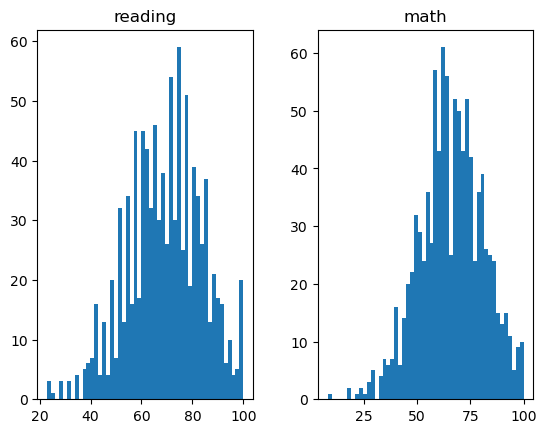

In [33]:
df[['reading', 'math']].hist(bins=50, grid=False);

#### Histograms for our selected variables (seaborn)

[seaborn.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html)

We can plot histogram in different plots using matplotlib subplots

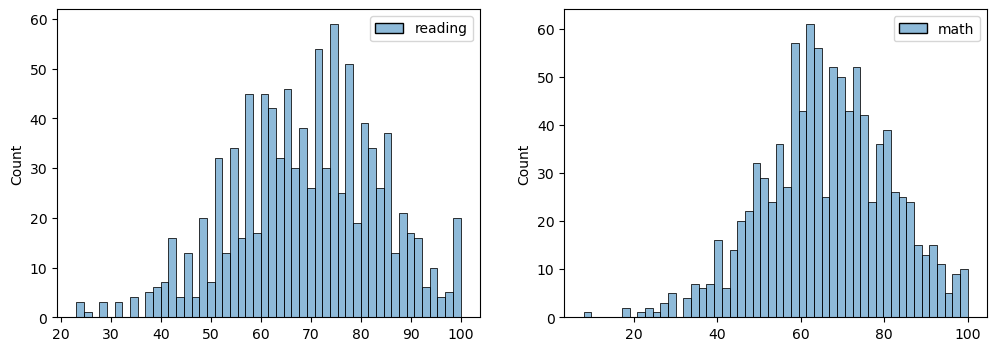

In [34]:
plt.figure(figsize=(12,4))
sns.histplot(df[['reading']], bins=50, ax=plt.subplot(121))
sns.histplot(df[['math']], bins=50, ax=plt.subplot(122));